<a href="https://colab.research.google.com/github/ryanchoigit/hyperbolicgat/blob/main/Step5d_Ablation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 5d: Ablation Study

Replicating Paper Table 2 (component ablation) and Table 3 (Euclidean vs Hyperbolic).

**Table 2 ablation variants (Paper Section 6.1):**
1. Temporal Convolution only (T-Conv)
2. T-Conv + Temporal Attention (T-Attn)
3. Hyperbolic Convolution + T-Conv (H-Conv + T-Conv)
4. H-Conv + T-Conv + T-Attn
5. Hyperbolic Attention + T-Conv (H-Attn + T-Conv)
6. Full HyperStockGAT (H-Attn + T-Conv + T-Attn)

**Table 3 comparison (Paper Section 6.2):**
- Euclidean GCN vs Hyperbolic Conv
- Euclidean GAT vs Hyperbolic Attention

---

## 0. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, json, time, copy, math, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as init
from torch.nn.modules.module import Module
from torch.nn.parameter import Parameter
import scipy.sparse as sp

warnings.filterwarnings('ignore')

SEED = 123456789
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

PROJECT_DIR = '/content/drive/MyDrive/hyperstockgat_v2'
DATA_DIR = os.path.join(PROJECT_DIR, 'data')
GRAPH_DIR = os.path.join(DATA_DIR, 'graph')
MODEL_DIR = os.path.join(PROJECT_DIR, 'models')
ABLATION_DIR = os.path.join(MODEL_DIR, 'ablation')
os.makedirs(ABLATION_DIR, exist_ok=True)

tickers = pd.read_csv(os.path.join(DATA_DIR, 'tickers.csv'))['ticker'].tolist()
N_STOCKS = len(tickers)
print(f'Stocks: {N_STOCKS}')

Device: cpu
Stocks: 1769


## 1. Load Data (from Step 5c)

In [ ]:
# Load precomputed features
eod_data = np.load(os.path.join(DATA_DIR, 'all_features.npy')).astype(np.float32)
dates_df = pd.read_csv(os.path.join(DATA_DIR, 'dates.csv'))
dates = dates_df['date'].values
prices_df = pd.read_csv(os.path.join(DATA_DIR, 'closing_prices.csv'))

price_data = prices_df.drop('Date', axis=1).values.T.astype(np.float32)
mask_data = (price_data > 0).astype(np.float32)
gt_data = eod_data[:, :, 0].copy()

# Splits (same as Step 5c)
total_days = len(dates)
VALID_INDEX = int(total_days * 0.60)
TEST_INDEX = int(total_days * 0.80)

print(f'Features: {eod_data.shape}')
print(f'Train: {VALID_INDEX} days, Val: {TEST_INDEX - VALID_INDEX} days, '
      f'Test: {total_days - TEST_INDEX} days')

# Load adjacency
def normalize_adj(mx):
    mx = mx + sp.eye(mx.shape[0])
    rowsum = np.array(mx.sum(1))
    r_inv = np.power(rowsum, -0.5).flatten()
    r_inv[np.isinf(r_inv)] = 0.
    r_mat = sp.diags(r_inv)
    return r_mat.dot(mx).dot(r_mat)

def sparse_mx_to_torch(sparse_mx):
    sparse_mx = sparse_mx.tocoo()
    indices = torch.from_numpy(
        np.vstack((sparse_mx.row, sparse_mx.col)).astype(np.int64))
    values = torch.Tensor(sparse_mx.data)
    shape = torch.Size(sparse_mx.shape)
    return torch.sparse_coo_tensor(indices, values, shape)

adj_binary = np.load(os.path.join(GRAPH_DIR, 'adj_binary.npy'))
adj_sparse = sp.coo_matrix(adj_binary, dtype=np.float32)
adj_normed = normalize_adj(adj_sparse)
adj_torch = sparse_mx_to_torch(adj_normed).to(DEVICE)
print(f'Adjacency: {adj_binary.shape}, edges={int(adj_binary.sum())//2:,}')

Features: (1769, 1509, 5)
Train: 905 days, Val: 302 days, Test: 302 days
Adjacency: (1769, 1769), edges=72,340


---
## 2. Model Components

All building blocks needed for every ablation variant.
Reused from Step 5c — Poincaré manifold, hyperbolic layers, temporal attention.

In [ ]:
# ============================================================
# POINCARÉ BALL MANIFOLD (from Step 5c)
# ============================================================
class Artanh(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        x = x.clamp(-1 + 1e-15, 1 - 1e-15)
        ctx.save_for_backward(x)
        z = x.double()
        return (torch.log_(1 + z).sub_(torch.log_(1 - z))).mul_(0.5).to(x.dtype)
    @staticmethod
    def backward(ctx, grad_output):
        input, = ctx.saved_tensors
        return grad_output / (1 - input ** 2)

def artanh(x):
    return Artanh.apply(x)

def tanh(x, clamp=15):
    return x.clamp(-clamp, clamp).tanh()

class PoincareBall:
    def __init__(self):
        self.name = 'PoincareBall'
        self.min_norm = 1e-15
        self.eps = {torch.float32: 4e-3, torch.float64: 1e-5}
    def proj(self, x, c):
        norm = torch.clamp_min(x.norm(dim=-1, keepdim=True, p=2), self.min_norm)
        maxnorm = (1 - self.eps[x.dtype]) / (c ** 0.5)
        cond = norm > maxnorm
        projected = x / norm * maxnorm
        return torch.where(cond, projected, x)
    def proj_tan0(self, u, c):
        return u
    def expmap0(self, u, c):
        sqrt_c = c ** 0.5
        u_norm = torch.clamp_min(u.norm(dim=-1, p=2, keepdim=True), self.min_norm)
        return tanh(sqrt_c * u_norm) * u / (sqrt_c * u_norm)
    def logmap0(self, p, c):
        sqrt_c = c ** 0.5
        p_norm = p.norm(dim=-1, p=2, keepdim=True).clamp_min(self.min_norm)
        return 1. / sqrt_c * artanh(sqrt_c * p_norm) / p_norm * p
    def mobius_add(self, x, y, c, dim=-1):
        x2 = x.pow(2).sum(dim=dim, keepdim=True)
        y2 = y.pow(2).sum(dim=dim, keepdim=True)
        xy = (x * y).sum(dim=dim, keepdim=True)
        num = (1 + 2 * c * xy + c * y2) * x + (1 - c * x2) * y
        denom = 1 + 2 * c * xy + c ** 2 * x2 * y2
        return num / denom.clamp_min(self.min_norm)
    def mobius_matvec(self, m, x, c):
        sqrt_c = c ** 0.5
        x_norm = x.norm(dim=-1, keepdim=True, p=2).clamp_min(self.min_norm)
        mx = x @ m.transpose(-1, -2)
        mx_norm = mx.norm(dim=-1, keepdim=True, p=2).clamp_min(self.min_norm)
        res_c = tanh(mx_norm / x_norm * artanh(sqrt_c * x_norm)) * mx / (mx_norm * sqrt_c)
        cond = (mx == 0).prod(-1, keepdim=True, dtype=torch.uint8)
        res_0 = torch.zeros(1, dtype=res_c.dtype, device=res_c.device)
        return torch.where(cond, res_0, res_c)

print('✅ PoincareBall manifold')

✅ PoincareBall manifold


In [ ]:
# ============================================================
# HYPERBOLIC LAYERS (from Step 5c)
# ============================================================
class HypLinear(nn.Module):
    def __init__(self, manifold, in_features, out_features, c, dropout, use_bias):
        super().__init__()
        self.manifold = manifold
        self.c = c
        self.dropout = dropout
        self.use_bias = use_bias
        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))
        self.bias = nn.Parameter(torch.Tensor(out_features))
        init.xavier_uniform_(self.weight, gain=math.sqrt(2))
        init.constant_(self.bias, 0)
    def forward(self, x):
        drop_weight = F.dropout(self.weight, self.dropout, training=self.training)
        mv = self.manifold.mobius_matvec(drop_weight, x, self.c)
        res = self.manifold.proj(mv, self.c)
        if self.use_bias:
            bias = self.manifold.proj_tan0(self.bias.view(1, -1), self.c)
            hyp_bias = self.manifold.expmap0(bias, self.c)
            hyp_bias = self.manifold.proj(hyp_bias, self.c)
            res = self.manifold.mobius_add(res, hyp_bias, c=self.c)
            res = self.manifold.proj(res, self.c)
        return res

class DenseAtt(nn.Module):
    def __init__(self, in_features, dropout):
        super().__init__()
        self.linear = nn.Linear(2 * in_features, 1, bias=True)
    def forward(self, x, adj):
        n = x.size(0)
        x_left = x.unsqueeze(1).expand(-1, n, -1)
        x_right = x.unsqueeze(0).expand(n, -1, -1)
        x_cat = torch.cat((x_left, x_right), dim=2)
        att_adj = self.linear(x_cat).squeeze()
        att_adj = torch.sigmoid(att_adj)
        return torch.mul(adj.to_dense() if adj.is_sparse else adj, att_adj)

class HypAgg(nn.Module):
    def __init__(self, manifold, c, in_features, dropout, use_att):
        super().__init__()
        self.manifold = manifold
        self.c = c
        self.use_att = use_att
        if self.use_att:
            self.att = DenseAtt(in_features, dropout)
    def forward(self, x, adj):
        x_tangent = self.manifold.logmap0(x, c=self.c)
        if self.use_att:
            adj_att = self.att(x_tangent, adj)
            support_t = torch.matmul(adj_att, x_tangent)
        else:
            support_t = torch.spmm(adj, x_tangent) if adj.is_sparse else torch.mm(adj, x_tangent)
        return self.manifold.proj(self.manifold.expmap0(support_t, c=self.c), c=self.c)

class HypAct(nn.Module):
    def __init__(self, manifold, c_in, c_out, act):
        super().__init__()
        self.manifold = manifold
        self.c_in = c_in
        self.c_out = c_out
        self.act = act
    def forward(self, x):
        xt = self.act(self.manifold.logmap0(x, c=self.c_in))
        xt = self.manifold.proj_tan0(xt, c=self.c_out)
        return self.manifold.proj(self.manifold.expmap0(xt, c=self.c_out), c=self.c_out)

class HyperbolicGraphConvolution(nn.Module):
    def __init__(self, manifold, in_features, out_features, c_in, c_out,
                 dropout, act, use_bias, use_att):
        super().__init__()
        self.linear = HypLinear(manifold, in_features, out_features, c_in, dropout, use_bias)
        self.agg = HypAgg(manifold, c_in, out_features, dropout, use_att)
        self.hyp_act = HypAct(manifold, c_in, c_out, act)
    def forward(self, input):
        x, adj = input
        h = self.linear(x)
        h = self.agg(h, adj)
        h = self.hyp_act(h)
        return h, adj

print('✅ Hyperbolic layers')

✅ Hyperbolic layers


In [ ]:
# ============================================================
# EUCLIDEAN GRAPH LAYERS (for Table 3 comparison)
# ============================================================
# Port of GraphConvolution from training/layers/layers.py
# Port of GraphAttentionLayer from training/layers/att_layers.py

class EuclideanGraphConv(nn.Module):
    """Standard GCN layer (Kipf & Welling 2017)."""
    def __init__(self, in_features, out_features, dropout, act, use_bias):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, use_bias)
        self.dropout = dropout
        self.act = act
    def forward(self, x, adj):
        h = self.linear(x)
        h = F.dropout(h, self.dropout, training=self.training)
        if adj.is_sparse:
            support = torch.spmm(adj, h)
        else:
            support = torch.mm(adj, h)
        return self.act(support)


class SpGraphAttentionHead(nn.Module):
    """Single sparse GAT attention head."""
    def __init__(self, in_features, out_features, dropout, alpha, activation):
        super().__init__()
        self.W = nn.Parameter(torch.zeros(in_features, out_features))
        nn.init.xavier_normal_(self.W.data, gain=1.414)
        self.a = nn.Parameter(torch.zeros(1, 2 * out_features))
        nn.init.xavier_normal_(self.a.data, gain=1.414)
        self.dropout = nn.Dropout(dropout)
        self.leakyrelu = nn.LeakyReLU(alpha)
        self.act = activation
        self.out_features = out_features

    def forward(self, x, adj):
        N = x.size(0)
        h = torch.mm(x, self.W)
        # Dense attention (compatible with sparse adj)
        a_input = torch.cat([
            h.repeat(1, N).view(N * N, -1),
            h.repeat(N, 1)
        ], dim=1).view(N, N, 2 * self.out_features)
        e = self.leakyrelu(torch.matmul(a_input, self.a.t()).squeeze(2))
        # Mask with adjacency
        adj_dense = adj.to_dense() if adj.is_sparse else adj
        zero_vec = -9e15 * torch.ones_like(e)
        attention = torch.where(adj_dense > 0, e, zero_vec)
        attention = F.softmax(attention, dim=1)
        attention = self.dropout(attention)
        h_prime = torch.matmul(attention, h)
        return self.act(h_prime)


class EuclideanGAT(nn.Module):
    """Multi-head Euclidean Graph Attention Network."""
    def __init__(self, in_features, out_features, dropout, act, alpha=0.2, n_heads=4):
        super().__init__()
        assert out_features % n_heads == 0
        head_dim = out_features // n_heads
        self.heads = nn.ModuleList([
            SpGraphAttentionHead(in_features, head_dim, dropout, alpha, act)
            for _ in range(n_heads)
        ])
    def forward(self, x, adj):
        return torch.cat([head(x, adj) for head in self.heads], dim=1)

print('✅ Euclidean GCN and GAT layers')

✅ Euclidean GCN and GAT layers


In [ ]:
# ============================================================
# TEMPORAL ATTENTION (from Step 5c)
# ============================================================
class TemporalAttention(nn.Module):
    def __init__(self, in_channels, num_of_vertices, num_of_timesteps):
        super().__init__()
        self.U1 = nn.Parameter(torch.FloatTensor(num_of_vertices))
        self.U2 = nn.Parameter(torch.FloatTensor(in_channels, num_of_vertices))
        self.U3 = nn.Parameter(torch.FloatTensor(in_channels))
        self.be = nn.Parameter(torch.FloatTensor(1, num_of_timesteps, num_of_timesteps))
        self.Ve = nn.Parameter(torch.FloatTensor(num_of_timesteps, num_of_timesteps))
    def forward(self, x):
        _, nv, nf, nt = x.shape
        lhs = torch.matmul(torch.matmul(x.permute(0, 3, 2, 1), self.U1), self.U2)
        rhs = torch.matmul(self.U3, x)
        product = torch.matmul(lhs, rhs)
        E = torch.matmul(self.Ve, torch.sigmoid(product + self.be))
        return F.softmax(E, dim=1)

print('✅ Temporal Attention')

✅ Temporal Attention


---
## 3. Configurable Ablation Model

A single model class with flags to enable/disable each component,
matching all 6 variants from Paper Table 2 + Euclidean variants for Table 3.

| Variant | T-Conv | T-Attn | Graph | Hyp | Graph-Attn |
|---------|--------|--------|-------|-----|------------|
| T-Conv | ✓ | | | | |
| T-Conv+T-Attn | ✓ | ✓ | | | |
| H-Conv+T-Conv | ✓ | | ✓ | ✓ | |
| H-Conv+T-Conv+T-Attn | ✓ | ✓ | ✓ | ✓ | |
| H-Attn+T-Conv | ✓ | | ✓ | ✓ | ✓ |
| Full HyperStockGAT | ✓ | ✓ | ✓ | ✓ | ✓ |
| GCN+T-Conv+T-Attn | ✓ | ✓ | ✓ | | |
| GAT+T-Conv+T-Attn | ✓ | ✓ | ✓ | | ✓ |

In [ ]:
# ============================================================
# CONFIGURABLE ABLATION MODEL
# ============================================================

class AblationModel(nn.Module):
    """
    Configurable model for ablation study.

    Args:
        use_temporal_attn: Enable temporal attention (T-Attn)
        use_graph: Enable graph convolution layer
        use_hyperbolic: Use hyperbolic (True) or Euclidean (False) graph conv
        use_graph_attn: Use attention in graph conv (GAT vs GCN)
    """
    def __init__(self, n_stocks, feat_dim=5, hidden_dim=128, lookback=4,
                 num_graph_layers=1, dropout=0.0, curvature=1.0,
                 use_temporal_attn=True, use_graph=True,
                 use_hyperbolic=True, use_graph_attn=True):
        super().__init__()
        self.n_stocks = n_stocks
        self.feat_dim = feat_dim
        self.hidden_dim = hidden_dim
        self.lookback = lookback
        self.use_temporal_attn = use_temporal_attn
        self.use_graph = use_graph
        self.use_hyperbolic = use_hyperbolic
        self.use_graph_attn = use_graph_attn

        self.manifold = PoincareBall()
        self.curvatures = [torch.tensor([curvature]).to(DEVICE) for _ in range(3)]

        # --- Temporal Attention (pre-graph) ---
        if use_temporal_attn:
            self.temp_attn1 = TemporalAttention(feat_dim, n_stocks, lookback)

        # --- Temporal Conv (always present) ---
        self.time_conv1 = nn.Conv2d(feat_dim, feat_dim,
                                     kernel_size=(1, 3), stride=(1, 1), padding=(0, 1))

        # --- Graph layer ---
        if use_graph:
            if use_hyperbolic:
                # Hyperbolic graph conv (with or without attention)
                self.graph_layer = HyperbolicGraphConvolution(
                    self.manifold, feat_dim, hidden_dim,
                    self.curvatures[0], self.curvatures[1],
                    dropout, F.relu, True, use_graph_attn)
            else:
                # Euclidean graph conv
                if use_graph_attn:
                    self.graph_layer = EuclideanGAT(
                        feat_dim, hidden_dim, dropout, F.elu, alpha=0.2, n_heads=4)
                else:
                    self.graph_layer = EuclideanGraphConv(
                        feat_dim, hidden_dim, dropout, F.relu, True)
            graph_out_dim = hidden_dim
        else:
            graph_out_dim = feat_dim  # No graph: features pass through unchanged

        # --- Temporal Attention (post-graph) ---
        if use_temporal_attn:
            self.temp_attn2 = TemporalAttention(feat_dim, n_stocks, lookback)

        # --- Temporal Conv 2 ---
        self.time_conv2 = nn.Conv2d(feat_dim, feat_dim,
                                     kernel_size=(1, 3), stride=(1, 1), padding=(0, 1))

        # --- Output ---
        self.output_conv = nn.Conv2d(lookback, 1,
                                      kernel_size=(1, 3), stride=(1, 1), padding=(0, 1))
        self.output_linear = nn.Linear(graph_out_dim, 1)

    def forward(self, x, adj):
        # x: (N, T, F) → (1, N, F, T)
        x_orig = x.unsqueeze(0).permute(0, 1, 3, 2)
        B, N, Fin, T = x_orig.shape

        # === Stage 1: Optional Temporal Attention + Conv ===
        if self.use_temporal_attn:
            temp_E = self.temp_attn1(x_orig)
            x_at = torch.matmul(
                x_orig.reshape(B, -1, T), temp_E
            ).reshape(B, N, Fin, T)
        else:
            x_at = x_orig

        x_at = self.time_conv1(
            x_at.permute(0, 2, 1, 3)  # (1, F, N, T)
        ).reshape(B, N, Fin, T)

        # === Stage 2: Per-timestep graph convolution (if enabled) ===
        if self.use_graph:
            outputs = []
            for t in range(T):
                y = x_at[:, :, :, t].reshape(N, Fin)
                if self.use_hyperbolic:
                    y_tan = self.manifold.proj_tan0(y, self.curvatures[0])
                    y_hyp = self.manifold.expmap0(y_tan, c=self.curvatures[0])
                    y_hyp = self.manifold.proj(y_hyp, c=self.curvatures[0])
                    h, _ = self.graph_layer((y_hyp, adj))
                    h_out = self.manifold.logmap0(h, c=self.curvatures[-1])
                else:
                    h_out = self.graph_layer(y, adj)
                outputs.append(h_out.reshape(1, N, self.hidden_dim))
            spatial = torch.stack(outputs).permute(1, 0, 2, 3)  # (1, T, N, D)
            h = spatial.permute(0, 2, 3, 1)  # (1, N, D, T)
        else:
            h = x_at  # No graph: (1, N, F, T)

        # === Stage 3: Optional Temporal Attention + Conv ===
        # Reference code uses original x for second temporal attention
        if self.use_temporal_attn:
            temp_E2 = self.temp_attn2(x_orig)
            x_at2 = torch.matmul(
                x_orig.reshape(B, -1, T), temp_E2
            ).reshape(B, N, Fin, T)
        else:
            x_at2 = x_orig

        x_at2 = self.time_conv2(
            x_at2.permute(0, 2, 1, 3)
        ).reshape(B, T, N, Fin)

        # === Stage 4: Output ===
        if self.use_graph:
            # Use spatially processed features
            h_decode = h.permute(0, 3, 1, 2)  # (1, T, N, D)
        else:
            # Use temporally processed features
            h_decode = x_at2  # already (1, T, N, F)

        out = self.output_conv(h_decode)  # (1, 1, N, D)
        out = out.squeeze(0).squeeze(0)   # (N, D)
        out = F.leaky_relu(self.output_linear(out), 0.2)  # (N, 1)
        return out


# Quick shape test
_test_model = AblationModel(N_STOCKS).to(DEVICE)
_test_x = torch.randn(N_STOCKS, 4, 5).to(DEVICE)
_test_adj = torch.eye(N_STOCKS).to_sparse().to(DEVICE)
with torch.no_grad():
    _test_out = _test_model(_test_x, _test_adj)
assert _test_out.shape == (N_STOCKS, 1)
del _test_model, _test_x, _test_adj, _test_out
torch.cuda.empty_cache()
print('✅ AblationModel defined and tested')

✅ AblationModel defined and tested


---
## 4. Loss, Evaluation, and Training (from Step 5c)

In [ ]:
# ============================================================
# LOSS, EVAL, BATCHING (identical to Step 5c)
# ============================================================

def weighted_mse_loss(pred, target, weight):
    return torch.mean(weight * (pred - target) ** 2)

def trr_loss_mse_rank(pred, base_price, ground_truth, mask, alpha, n_stocks):
    return_ratio = torch.div((pred - base_price), base_price)
    reg_loss = weighted_mse_loss(return_ratio, ground_truth, mask)
    all_ones = torch.ones(n_stocks, 1).to(DEVICE)
    pre_pw_dif = (torch.matmul(return_ratio, all_ones.t())
                  - torch.matmul(all_ones, return_ratio.t()))
    gt_pw_dif = (torch.matmul(all_ones, ground_truth.t())
                 - torch.matmul(ground_truth, all_ones.t()))
    mask_pw = torch.matmul(mask, mask.t())
    rank_loss = torch.mean(F.relu(pre_pw_dif * gt_pw_dif * mask_pw))
    loss = reg_loss + alpha * rank_loss
    del mask_pw, gt_pw_dif, pre_pw_dif, all_ones
    return loss, reg_loss, rank_loss, return_ratio

def evaluate(prediction, ground_truth, mask, top_k=5):
    performance = {}
    bt_long = 1.0
    sharpe_li = []
    for day in range(prediction.shape[1]):
        rank_pred = np.argsort(prediction[:, day])
        pred_topk = set()
        for j in range(1, prediction.shape[0] + 1):
            cur = rank_pred[-j]
            if mask[cur][day] < 0.5:
                continue
            if len(pred_topk) < top_k:
                pred_topk.add(cur)
        daily_return = sum(ground_truth[s][day] for s in pred_topk) / max(len(pred_topk), 1)
        bt_long += daily_return
        sharpe_li.append(daily_return)
    sharpe_arr = np.array(sharpe_li)
    std = np.std(sharpe_arr)
    performance[f'irr@{top_k}'] = bt_long - 1.0
    performance[f'sharpe@{top_k}'] = (np.mean(sharpe_arr) / std) * 15.87 if std > 1e-10 else 0.0
    return performance

def get_batch(eod_data, mask_data, price_data, gt_data, offset, seq_len, steps=1):
    mask_batch = np.min(mask_data[:, offset: offset + seq_len + steps], axis=1)
    return (
        eod_data[:, offset:offset + seq_len, :],
        np.expand_dims(mask_batch, axis=1),
        np.expand_dims(price_data[:, offset + seq_len - 1], axis=1),
        np.expand_dims(gt_data[:, offset + seq_len + steps - 1], axis=1),
    )

print('✅ Loss, evaluation, batching defined')

✅ Loss, evaluation, batching defined


In [ ]:
# ============================================================
# ABLATION TRAINING FUNCTION
# ============================================================

def train_ablation(model, name, eod_data, mask_data, price_data, gt_data,
                   adj, hp, valid_index, test_index, n_runs=3):
    """
    Train a model variant for n_runs and return mean ± std results.
    Paper Table 2: mean of 10 independent runs.
    We use 3 runs for speed (increase to 10 for final results).
    """
    seq_len = hp['lookback']
    steps = 1
    alpha = hp['alpha']
    epochs = hp['epochs']
    lr = hp['lr']
    n_stocks = eod_data.shape[0]
    trade_dates = eod_data.shape[1]
    n_train = valid_index - seq_len - steps + 1

    all_results = []

    for run in range(n_runs):
        print(f'  Run {run+1}/{n_runs}...', end=' ')
        run_seed = SEED + run * 1000
        torch.manual_seed(run_seed)
        np.random.seed(run_seed)

        # Re-init weights
        for p in model.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
            else:
                nn.init.uniform_(p)

        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        batch_offsets = np.arange(start=0, stop=valid_index, dtype=int)

        best_val_sr = -999
        best_test_result = None

        for epoch in range(epochs):
            np.random.shuffle(batch_offsets)
            model.train()
            for j in range(n_train):
                emb, mask, price, gt = get_batch(
                    eod_data, mask_data, price_data, gt_data,
                    offset=batch_offsets[j], seq_len=seq_len, steps=steps)
                optimizer.zero_grad()
                pred = model(torch.FloatTensor(emb).to(DEVICE), adj)
                loss, _, _, _ = trr_loss_mse_rank(
                    pred, torch.FloatTensor(price).to(DEVICE),
                    torch.FloatTensor(gt).to(DEVICE),
                    torch.FloatTensor(mask).to(DEVICE), alpha, n_stocks)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            # Validate
            model.eval()
            val_pred = np.zeros([n_stocks, test_index - valid_index])
            val_gt_arr = np.zeros([n_stocks, test_index - valid_index])
            val_mask_arr = np.zeros([n_stocks, test_index - valid_index])
            with torch.no_grad():
                for off in range(valid_index - seq_len - steps + 1,
                                  test_index - seq_len - steps + 1):
                    emb, mask, price, gt = get_batch(
                        eod_data, mask_data, price_data, gt_data,
                        offset=off, seq_len=seq_len, steps=steps)
                    pred = model(torch.FloatTensor(emb).to(DEVICE), adj)
                    _, _, _, rr = trr_loss_mse_rank(
                        pred, torch.FloatTensor(price).to(DEVICE),
                        torch.FloatTensor(gt).to(DEVICE),
                        torch.FloatTensor(mask).to(DEVICE), alpha, n_stocks)
                    col = off - (valid_index - seq_len - steps + 1)
                    val_pred[:, col] = rr.detach().cpu().numpy()[:, 0]
                    val_gt_arr[:, col] = gt[:, 0]
                    val_mask_arr[:, col] = mask[:, 0]
            val_perf = evaluate(val_pred, val_gt_arr, val_mask_arr)

            # Test
            test_pred = np.zeros([n_stocks, trade_dates - test_index])
            test_gt_arr = np.zeros([n_stocks, trade_dates - test_index])
            test_mask_arr = np.zeros([n_stocks, trade_dates - test_index])
            with torch.no_grad():
                for off in range(test_index - seq_len - steps + 1,
                                  trade_dates - seq_len - steps + 1):
                    emb, mask, price, gt = get_batch(
                        eod_data, mask_data, price_data, gt_data,
                        offset=off, seq_len=seq_len, steps=steps)
                    pred = model(torch.FloatTensor(emb).to(DEVICE), adj)
                    _, _, _, rr = trr_loss_mse_rank(
                        pred, torch.FloatTensor(price).to(DEVICE),
                        torch.FloatTensor(gt).to(DEVICE),
                        torch.FloatTensor(mask).to(DEVICE), alpha, n_stocks)
                    col = off - (test_index - seq_len - steps + 1)
                    test_pred[:, col] = rr.detach().cpu().numpy()[:, 0]
                    test_gt_arr[:, col] = gt[:, 0]
                    test_mask_arr[:, col] = mask[:, 0]
            test_perf = evaluate(test_pred, test_gt_arr, test_mask_arr)

            if val_perf['sharpe@5'] > best_val_sr:
                best_val_sr = val_perf['sharpe@5']
                best_test_result = {
                    'val_sr': val_perf['sharpe@5'],
                    'val_irr': val_perf['irr@5'],
                    'test_sr': test_perf['sharpe@5'],
                    'test_irr': test_perf['irr@5'],
                }

        all_results.append(best_test_result)
        print(f'SR@5={best_test_result["test_sr"]:.3f}, IRR@5={best_test_result["test_irr"]:.3f}')

    # Compute mean ± std
    srs = [r['test_sr'] for r in all_results]
    irrs = [r['test_irr'] for r in all_results]
    summary = {
        'name': name,
        'test_sr_mean': np.mean(srs),
        'test_sr_std': np.std(srs),
        'test_irr_mean': np.mean(irrs),
        'test_irr_std': np.std(irrs),
        'runs': all_results,
    }
    print(f'  → {name}: SR@5={summary["test_sr_mean"]:.3f}±{summary["test_sr_std"]:.3f}, '
          f'IRR@5={summary["test_irr_mean"]:.3f}±{summary["test_irr_std"]:.3f}')
    return summary

print('✅ Ablation training function defined')

✅ Ablation training function defined


---
## 5. Run Ablation Study (Paper Table 2)

Each variant is trained for 3 runs (increase to 10 for final results).
Paper reports mean of 10 independent runs.

In [ ]:
# ============================================================
# HYPERPARAMETERS (same as Step 5c)
# ============================================================
HP = {
    'feat_dim': 5,
    'hidden_dim': 128,
    'lookback': 4,
    'dropout': 0.0,
    'curvature': 1.0,
    'lr': 8e-4,
    'alpha': 10,
    'epochs': 50,
}

N_RUNS = 3  # Paper uses 10; set to 3 for speed

# Define all ablation variants matching Paper Table 2
ABLATION_CONFIGS = {
    '1_TConv': {
        'use_temporal_attn': False,
        'use_graph': False,
        'use_hyperbolic': False,
        'use_graph_attn': False,
    },
    '2_TConv+TAttn': {
        'use_temporal_attn': True,
        'use_graph': False,
        'use_hyperbolic': False,
        'use_graph_attn': False,
    },
    '3_HConv+TConv': {
        'use_temporal_attn': False,
        'use_graph': True,
        'use_hyperbolic': True,
        'use_graph_attn': False,
    },
    '4_HConv+TConv+TAttn': {
        'use_temporal_attn': True,
        'use_graph': True,
        'use_hyperbolic': True,
        'use_graph_attn': False,
    },
    '5_HAttn+TConv': {
        'use_temporal_attn': False,
        'use_graph': True,
        'use_hyperbolic': True,
        'use_graph_attn': True,
    },
    '6_HyperStockGAT': {
        'use_temporal_attn': True,
        'use_graph': True,
        'use_hyperbolic': True,
        'use_graph_attn': True,
    },
}

# Table 3: Euclidean vs Hyperbolic
TABLE3_CONFIGS = {
    '7_GCN+TConv+TAttn': {
        'use_temporal_attn': True,
        'use_graph': True,
        'use_hyperbolic': False,
        'use_graph_attn': False,
    },
    '8_GAT+TConv+TAttn': {
        'use_temporal_attn': True,
        'use_graph': True,
        'use_hyperbolic': False,
        'use_graph_attn': True,
    },
}

ALL_CONFIGS = {**ABLATION_CONFIGS, **TABLE3_CONFIGS}

print(f'Ablation variants: {len(ABLATION_CONFIGS)} (Table 2)')
print(f'Euclidean variants: {len(TABLE3_CONFIGS)} (Table 3)')
print(f'Total: {len(ALL_CONFIGS)} variants × {N_RUNS} runs = {len(ALL_CONFIGS) * N_RUNS} training runs')
print(f'Estimated time: ~{len(ALL_CONFIGS) * N_RUNS * 3.5 / 60:.0f} hours on A100')

Ablation variants: 6 (Table 2)
Euclidean variants: 2 (Table 3)
Total: 8 variants × 3 runs = 24 training runs
Estimated time: ~1 hours on A100


In [ ]:
# ============================================================
# RUN ALL ABLATIONS
# ============================================================
all_results = {}

for config_name, config in ALL_CONFIGS.items():
    print(f'\n{"="*60}')
    print(f'  {config_name}')
    print(f'  TAttn={config["use_temporal_attn"]}, Graph={config["use_graph"]}, '
          f'Hyp={config["use_hyperbolic"]}, GAttn={config["use_graph_attn"]}')
    print(f'{"="*60}')

    model = AblationModel(
        n_stocks=N_STOCKS,
        feat_dim=HP['feat_dim'],
        hidden_dim=HP['hidden_dim'],
        lookback=HP['lookback'],
        dropout=HP['dropout'],
        curvature=HP['curvature'],
        use_temporal_attn=config['use_temporal_attn'],
        use_graph=config['use_graph'],
        use_hyperbolic=config['use_hyperbolic'],
        use_graph_attn=config['use_graph_attn'],
    ).to(DEVICE)

    result = train_ablation(
        model, config_name,
        eod_data, mask_data, price_data, gt_data,
        adj_torch, HP, VALID_INDEX, TEST_INDEX,
        n_runs=N_RUNS
    )
    all_results[config_name] = result

    # Save incrementally
    with open(os.path.join(ABLATION_DIR, 'ablation_results.json'), 'w') as f:
        json.dump({k: {kk: vv for kk, vv in v.items() if kk != 'runs'}
                   for k, v in all_results.items()}, f, indent=2)

    # Free memory
    del model
    torch.cuda.empty_cache()

print(f'\n\n✅ All {len(ALL_CONFIGS)} ablation variants complete!')


  1_TConv
  TAttn=False, Graph=False, Hyp=False, GAttn=False
  Run 1/3... SR@5=4.268, IRR@5=2.735
  Run 2/3... SR@5=4.965, IRR@5=3.544
  Run 3/3... SR@5=4.537, IRR@5=2.947
  → 1_TConv: SR@5=4.590±0.287, IRR@5=3.075±0.343

  2_TConv+TAttn
  TAttn=True, Graph=False, Hyp=False, GAttn=False
  Run 1/3... SR@5=4.738, IRR@5=3.027
  Run 2/3... SR@5=5.171, IRR@5=3.404
  Run 3/3... SR@5=4.381, IRR@5=3.135
  → 2_TConv+TAttn: SR@5=4.764±0.323, IRR@5=3.189±0.158

  3_HConv+TConv
  TAttn=False, Graph=True, Hyp=True, GAttn=False
  Run 1/3... SR@5=4.072, IRR@5=2.939
  Run 2/3... SR@5=5.216, IRR@5=3.742
  Run 3/3... SR@5=4.898, IRR@5=3.476
  → 3_HConv+TConv: SR@5=4.729±0.482, IRR@5=3.386±0.334

  4_HConv+TConv+TAttn
  TAttn=True, Graph=True, Hyp=True, GAttn=False
  Run 1/3... SR@5=5.202, IRR@5=3.878
  Run 2/3... SR@5=5.198, IRR@5=3.648
  Run 3/3... SR@5=4.552, IRR@5=3.223
  → 4_HConv+TConv+TAttn: SR@5=4.984±0.305, IRR@5=3.583±0.271

  5_HAttn+TConv
  TAttn=False, Graph=True, Hyp=True, GAttn=True
  Run

---
## 6. Results Comparison

In [ ]:
# ============================================================
# TABLE 2 RECREATION: Component Ablation
# ============================================================
with open(os.path.join(ABLATION_DIR, 'ablation_results.json')) as f:
    saved = json.load(f)
all_results = saved
print('TABLE 2: Ablation over HyperStockGAT Components')
print('=' * 75)
print(f'{"Model Component":<30} {"SR@5":>12} {"IRR@5":>12}')
print('-' * 75)

table2_keys = [k for k in ABLATION_CONFIGS.keys()]
for key in table2_keys:
    r = all_results[key]
    print(f'{key:<30} {r["test_sr_mean"]:>6.3f}±{r["test_sr_std"]:.3f} '
          f'{r["test_irr_mean"]:>6.3f}±{r["test_irr_std"]:.3f}')

print()
print('Paper Table 2 (NASDAQ, 1026 stocks, 2013-2017):')
print(f'{"T-Conv":<30} {"0.98":>12} {"0.23":>12}')
print(f'{"T-Conv+T-Attn":<30} {"1.01":>12} {"0.26":>12}')
print(f'{"H-Conv+T-Conv":<30} {"1.20":>12} {"0.30":>12}')
print(f'{"H-Conv+T-Conv+T-Attn":<30} {"1.30":>12} {"0.38":>12}')
print(f'{"H-Attn+T-Conv":<30} {"1.35":>12} {"0.41":>12}')
print(f'{"HyperStockGAT":<30} {"1.40":>12} {"0.44":>12}')

TABLE 2: Ablation over HyperStockGAT Components
Model Component                        SR@5        IRR@5
---------------------------------------------------------------------------
1_TConv                         4.590±0.287  3.075±0.343
2_TConv+TAttn                   4.764±0.323  3.189±0.158
3_HConv+TConv                   4.729±0.482  3.386±0.334
4_HConv+TConv+TAttn             4.984±0.305  3.583±0.271
5_HAttn+TConv                   5.203±0.329  3.979±0.217
6_HyperStockGAT                 4.519±0.682  3.341±0.625

Paper Table 2 (NASDAQ, 1026 stocks, 2013-2017):
T-Conv                                 0.98         0.23
T-Conv+T-Attn                          1.01         0.26
H-Conv+T-Conv                          1.20         0.30
H-Conv+T-Conv+T-Attn                   1.30         0.38
H-Attn+T-Conv                          1.35         0.41
HyperStockGAT                          1.40         0.44


In [ ]:
print(os.listdir(ABLATION_DIR))

['ablation_results.json']


In [ ]:
# ============================================================
# TABLE 3 RECREATION: Euclidean vs Hyperbolic
# ============================================================
print('TABLE 3: Euclidean vs Hyperbolic Graph Learning')
print('=' * 75)
print(f'{"Model":<30} {"SR@5":>12} {"IRR@5":>12}')
print('-' * 75)

table3_keys = ['2_TConv+TAttn',       # Baseline (no graph)
               '7_GCN+TConv+TAttn',   # +Euclidean GCN
               '4_HConv+TConv+TAttn',  # +Hyperbolic Conv
               '8_GAT+TConv+TAttn',   # +Euclidean GAT
               '6_HyperStockGAT']     # +Hyperbolic Attn

for key in table3_keys:
    r = all_results[key]
    print(f'{key:<30} {r["test_sr_mean"]:>6.3f}±{r["test_sr_std"]:.3f} '
          f'{r["test_irr_mean"]:>6.3f}±{r["test_irr_std"]:.3f}')

# Compute % improvement
if '7_GCN+TConv+TAttn' in all_results and '4_HConv+TConv+TAttn' in all_results:
    gcn_sr = all_results['7_GCN+TConv+TAttn']['test_sr_mean']
    hconv_sr = all_results['4_HConv+TConv+TAttn']['test_sr_mean']
    print(f'\n  % Improvement HConv over GCN: {(hconv_sr - gcn_sr) / abs(gcn_sr) * 100:.1f}%')
    print(f'  (Paper: 41.3% on NASDAQ)')

if '8_GAT+TConv+TAttn' in all_results and '6_HyperStockGAT' in all_results:
    gat_sr = all_results['8_GAT+TConv+TAttn']['test_sr_mean']
    hattn_sr = all_results['6_HyperStockGAT']['test_sr_mean']
    print(f'  % Improvement HAttn over GAT: {(hattn_sr - gat_sr) / abs(gat_sr) * 100:.1f}%')
    print(f'  (Paper: 41.4% on NASDAQ)')

TABLE 3: Euclidean vs Hyperbolic Graph Learning
Model                                  SR@5        IRR@5
---------------------------------------------------------------------------
2_TConv+TAttn                   4.764±0.323  3.189±0.158
7_GCN+TConv+TAttn               4.893±0.507  3.552±0.470
4_HConv+TConv+TAttn             4.984±0.305  3.583±0.271
8_GAT+TConv+TAttn               4.305±0.467  3.313±0.473
6_HyperStockGAT                 4.519±0.682  3.341±0.625

  % Improvement HConv over GCN: 1.9%
  (Paper: 41.3% on NASDAQ)
  % Improvement HAttn over GAT: 5.0%
  (Paper: 41.4% on NASDAQ)


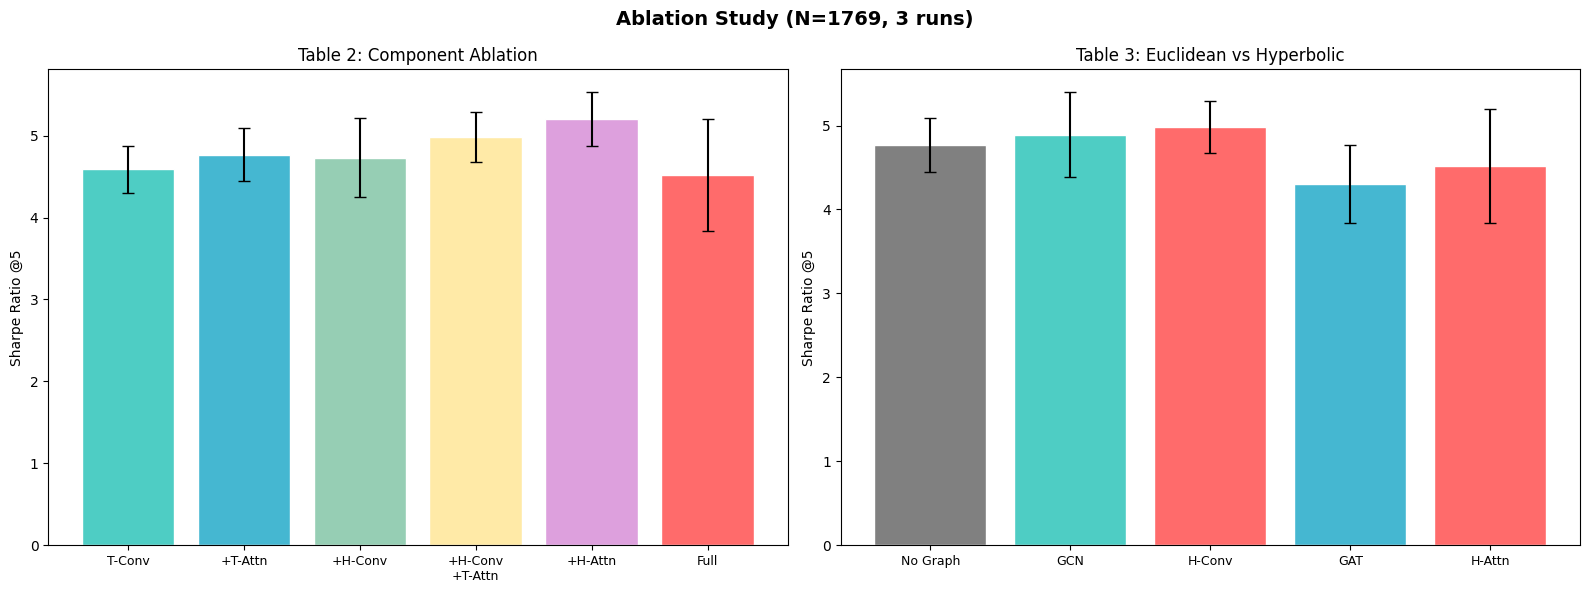

In [ ]:
# ============================================================
# ABLATION BAR CHART
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Table 2 bar chart
names_t2 = ['T-Conv', '+T-Attn', '+H-Conv', '+H-Conv\n+T-Attn', '+H-Attn', 'Full']
srs_t2 = [all_results[k]['test_sr_mean'] for k in table2_keys]
srs_t2_std = [all_results[k]['test_sr_std'] for k in table2_keys]
colors_t2 = ['#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#FF6B6B']

axes[0].bar(range(len(names_t2)), srs_t2, yerr=srs_t2_std,
            color=colors_t2, edgecolor='white', capsize=4)
axes[0].set_xticks(range(len(names_t2)))
axes[0].set_xticklabels(names_t2, fontsize=9)
axes[0].set_ylabel('Sharpe Ratio @5')
axes[0].set_title('Table 2: Component Ablation')

# Table 3 bar chart
names_t3 = ['No Graph', 'GCN', 'H-Conv', 'GAT', 'H-Attn']
srs_t3 = [all_results[k]['test_sr_mean'] for k in table3_keys]
srs_t3_std = [all_results[k]['test_sr_std'] for k in table3_keys]
colors_t3 = ['gray', '#4ECDC4', '#FF6B6B', '#45B7D1', '#FF6B6B']

axes[1].bar(range(len(names_t3)), srs_t3, yerr=srs_t3_std,
            color=colors_t3, edgecolor='white', capsize=4)
axes[1].set_xticks(range(len(names_t3)))
axes[1].set_xticklabels(names_t3, fontsize=9)
axes[1].set_ylabel('Sharpe Ratio @5')
axes[1].set_title('Table 3: Euclidean vs Hyperbolic')

plt.suptitle(f'Ablation Study (N={N_STOCKS}, {N_RUNS} runs)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(ABLATION_DIR, 'ablation_results.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# CONSISTENCY CHECKS vs PAPER
# ============================================================
print('CONSISTENCY CHECKS vs PAPER')
print('=' * 60)

# Check 1: Each component should add value (Table 2 ordering)
srs_ordered = [all_results[k]['test_sr_mean'] for k in table2_keys]
print('\nCheck 1: Component contributions should be monotonically increasing')
for i in range(len(table2_keys)):
    marker = '✅' if i == 0 or srs_ordered[i] >= srs_ordered[i-1] else '⚠️'
    print(f'  {marker} {table2_keys[i]}: SR={srs_ordered[i]:.3f}')

# Check 2: Hyperbolic > Euclidean (Table 3)
print('\nCheck 2: Hyperbolic should outperform Euclidean')
if '7_GCN+TConv+TAttn' in all_results and '4_HConv+TConv+TAttn' in all_results:
    gcn = all_results['7_GCN+TConv+TAttn']['test_sr_mean']
    hconv = all_results['4_HConv+TConv+TAttn']['test_sr_mean']
    marker = '✅' if hconv > gcn else '⚠️'
    print(f'  {marker} H-Conv ({hconv:.3f}) vs GCN ({gcn:.3f})')

if '8_GAT+TConv+TAttn' in all_results and '6_HyperStockGAT' in all_results:
    gat = all_results['8_GAT+TConv+TAttn']['test_sr_mean']
    hattn = all_results['6_HyperStockGAT']['test_sr_mean']
    marker = '✅' if hattn > gat else '⚠️'
    print(f'  {marker} H-Attn ({hattn:.3f}) vs GAT ({gat:.3f})')

# Check 3: Graph > No Graph
print('\nCheck 3: Graph methods should outperform non-graph')
no_graph = all_results['2_TConv+TAttn']['test_sr_mean']
with_graph = all_results['6_HyperStockGAT']['test_sr_mean']
marker = '✅' if with_graph > no_graph else '⚠️'
print(f'  {marker} HyperStockGAT ({with_graph:.3f}) vs T-Conv+T-Attn ({no_graph:.3f})')

# Check 4: Biggest improvement from graph component (paper observation)
print('\nCheck 4: Biggest improvement should come from adding graph conv (paper observation)')
improvements = []
for i in range(1, len(table2_keys)):
    delta = srs_ordered[i] - srs_ordered[i-1]
    improvements.append((table2_keys[i], delta))
    print(f'  {table2_keys[i]}: +{delta:.3f}')
biggest = max(improvements, key=lambda x: x[1])
print(f'  → Biggest improvement: {biggest[0]} (+{biggest[1]:.3f})')

print(f'\n  Paper found biggest improvement from adding H-Conv (Table 2)')

CONSISTENCY CHECKS vs PAPER

Check 1: Component contributions should be monotonically increasing
  ✅ 1_TConv: SR=4.590
  ✅ 2_TConv+TAttn: SR=4.764
  ⚠️ 3_HConv+TConv: SR=4.729
  ✅ 4_HConv+TConv+TAttn: SR=4.984
  ✅ 5_HAttn+TConv: SR=5.203
  ⚠️ 6_HyperStockGAT: SR=4.519

Check 2: Hyperbolic should outperform Euclidean
  ✅ H-Conv (4.984) vs GCN (4.893)
  ✅ H-Attn (4.519) vs GAT (4.305)

Check 3: Graph methods should outperform non-graph
  ⚠️ HyperStockGAT (4.519) vs T-Conv+T-Attn (4.764)

Check 4: Biggest improvement should come from adding graph conv (paper observation)
  2_TConv+TAttn: +0.174
  3_HConv+TConv: +-0.035
  4_HConv+TConv+TAttn: +0.255
  5_HAttn+TConv: +0.219
  6_HyperStockGAT: +-0.683
  → Biggest improvement: 4_HConv+TConv+TAttn (+0.255)

  Paper found biggest improvement from adding H-Conv (Table 2)


In [ ]:
# ============================================================
# SAVE FINAL RESULTS
# ============================================================
save_data = {
    'hyperparameters': HP,
    'n_stocks': N_STOCKS,
    'n_runs': N_RUNS,
    'results': {k: {kk: vv for kk, vv in v.items() if kk != 'runs'}
                for k, v in all_results.items()},
    'full_results': {k: v for k, v in all_results.items()},
}

with open(os.path.join(ABLATION_DIR, 'ablation_full_results.json'), 'w') as f:
    json.dump(save_data, f, indent=2, default=str)

print(f'Saved to {ABLATION_DIR}/')

print(f'\n{"="*60}')
print(f'  STEP 5d COMPLETE')
print(f'{"="*60}')
print(f'  Variants tested: {len(ALL_CONFIGS)}')
print(f'  Runs per variant: {N_RUNS}')
print(f'  Best model: {max(all_results, key=lambda k: all_results[k]["test_sr_mean"])}')
print(f'\n  Next: Step 5e (Paper Trading Integration)')

Saved to /content/drive/MyDrive/hyperstockgat_v2/models/ablation/

  STEP 5d COMPLETE
  Variants tested: 8
  Runs per variant: 3
  Best model: 5_HAttn+TConv

  Next: Step 5e (Paper Trading Integration)
